In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [5]:
sys.path.append('C:/Users/rishe/Dissertation')

In [6]:
EXP_ID = f'exp_11_gnn_ver_1'
# DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain_with_coords_final.parquet'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_1970.csv'

In [7]:
# df = pd.read_parquet(DATA_PATH)
df = pd.read_csv(DATA_PATH)

In [8]:
df.head()

,station_id,date,year,month,day,day_of_year,rainfall,district,station_type,lat,lon
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,MURSHIDABAD,None,24.31,88.36
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,MURSHIDABAD,None,24.31,88.36
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,MURSHIDABAD,None,24.31,88.36
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,MURSHIDABAD,None,24.31,88.36
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,MURSHIDABAD,None,24.31,88.36


In [8]:
df_long['station_id'].nunique()

293

In [9]:
df_long.shape

(4741665, 11)

### Data pre-processing

In [10]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,24.31,88.36,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,24.31,88.36,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,24.31,88.36,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,24.31,88.36,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,24.31,88.36,MURSHIDABAD,None


In [11]:
df = df_long[['station_id', 'lat', 'lon']].drop_duplicates()
df.head()

,station_id,lat,lon
0,AKRIGANJ,24.31,88.36
17166,ALGARAH,27.12,88.58
33237,ALIPUR,22.53,88.33
77067,ALIPURDUAR,26.47,89.55
97521,ALIPURDUAR,26.48,89.52


In [12]:
df['station_id'].nunique()

293

In [13]:
df.shape

(328, 3)

In [26]:
df

,station_id,lat,lon
0,AKRIGANJ,24.310000,88.360000
17166,ALGARAH,27.120000,88.580000
33237,ALIPUR,22.530000,88.330000
77067,ALIPURDUAR,26.470000,89.550000
97521,ALIPURDUAR,26.480000,89.520000
113227,ALIPURDUAR(CWC),26.498333,89.528333
119071,ALSHA,23.250000,86.170000
120167,AMBIKANAGAR,22.930000,86.770000
128934,AMLAGORA,22.770000,87.330000
147927,AMTA,22.580000,88.020000


In [30]:
df_long[df_long['station_id'] == 'LALBAGH'][['station_id', 'lat', 'lon', 'year']].drop_duplicates()

,station_id,lat,lon,year
2801835,LALBAGH,24.18,88.28,1901
2802200,LALBAGH,24.18,88.28,1902
2802565,LALBAGH,24.18,88.28,1903
2802930,LALBAGH,24.18,88.28,1904
2803296,LALBAGH,24.18,88.28,1905
2803661,LALBAGH,24.18,88.28,1906
2804026,LALBAGH,24.18,88.28,1907
2804391,LALBAGH,24.18,88.28,1908
2804757,LALBAGH,24.18,88.28,1909
2805122,LALBAGH,24.18,88.28,1910


In [18]:
# Check inconsistencies
latlon_check = df_long.groupby("station_id")[["lat","lon"]].nunique()

# stations with multiple coordinates
problem_stations = latlon_check[(latlon_check["lat"]>1) | (latlon_check["lon"]>1)]
print(problem_stations)

Empty DataFrame
Columns: [lat, lon]
Index: []


In [15]:
station_coords = (
    df_long.groupby("station_id")
    .agg({
        "lat": lambda x: x.mode().iloc[0], 
        "lon": lambda x: x.mode().iloc[0]
    })
    .reset_index()
)

print(len(station_coords)) # Should output 293
station_coords.head()


293


,station_id,lat,lon
0,AKRIGANJ,24.310000,88.360000
1,ALGARAH,27.120000,88.580000
2,ALIPUR,22.530000,88.330000
3,ALIPURDUAR,26.470000,89.550000
4,ALIPURDUAR(CWC),26.498333,89.528333


In [17]:
df_long = df_long.drop(columns=["lat","lon"])

df_long = df_long.merge(
    station_coords[["station_id","lat","lon"]],
    on="station_id",
    how="left"
)

In [19]:
df_long.station_id.nunique()

293

In [20]:
save_path = f'C:/Users/rishe/Dissertation/data/processed_rain_with_coords_final.parquet'
df_long.to_parquet(save_path, index=False)

### Stations plot

In [9]:
from utils.plotting_utils.plots import plot_station_map

In [10]:
shapefile_path = f'C:/Users/rishe/Dissertation/data/West_Bengal/District_shape_West_Bengal.shp'

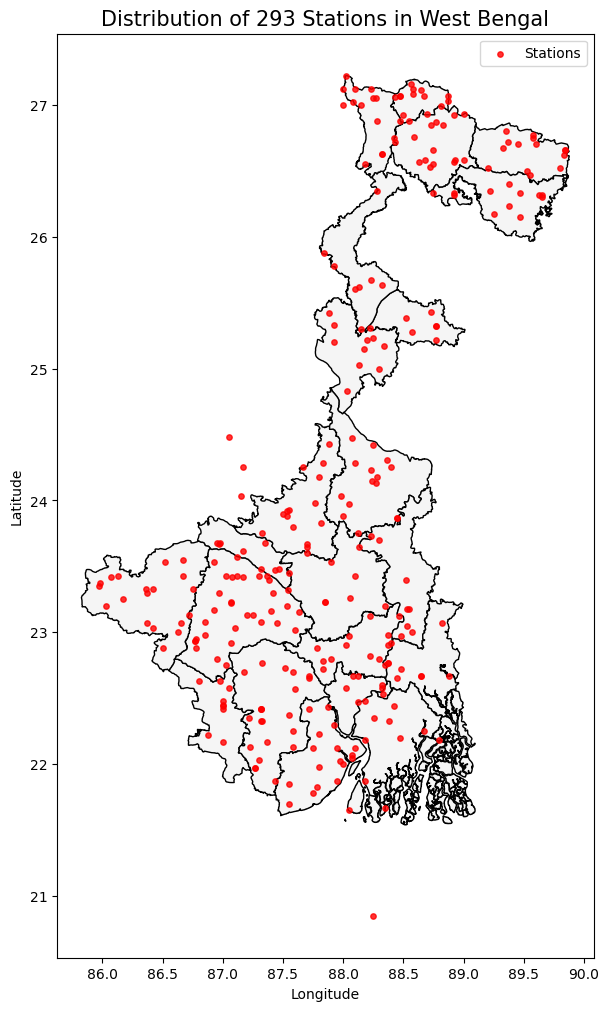

In [11]:
plot_station_map(df,shapefile_path)

In [12]:
wb_map = gpd.read_file(shapefile_path)

In [13]:
df_stations = df[['station_id', 'lat', 'lon']].drop_duplicates()

In [14]:
gdf_stations = gpd.GeoDataFrame(
        df_stations, 
        geometry=gpd.points_from_xy(df_stations.lon, df_stations.lat),
        crs="EPSG:4326" # EPSG:4326 is the standard coordinate system for raw Lat/Lon
    )

In [27]:

wb_polygon = wb_map.union_all()

gdf_stations["inside_wb"] = gdf_stations.within(wb_polygon)

outliers = gdf_stations[~gdf_stations["inside_wb"]]

print(outliers[['station_id','lat','lon']])

              station_id    lat    lon
1086987  CHENGMARI/DIANA  26.93  89.00
1115113           CHOPRA  26.35  88.28
1351797  DIAMOND HARBOUR  22.18  88.18
1463199            DUMKA  24.25  87.17
1813112        HELDIBARI  26.33  88.75
2060386         JANGIPUR  24.48  87.05
2142565            JHEPI  27.00  88.00
3455987       NARAYANPUR  24.25  87.67
3657969           PHALUT  27.22  88.02
3798956         RAIDIGHI  21.67  88.35
4191602        SANDHEADS  20.85  88.25
4582414           TANGLU  27.02  88.08
4590451          TANTLOI  24.03  87.15


In [28]:
df_long[df_long['station_id'] =='DUMKA'].head()

,station_id,date,year,month,day,day_of_year,rainfall,district,station_type,lat,lon
1463199,DUMKA,1901-01-01,1901,1,1,1,0.0,MURSHIDABAD,None,24.25,87.17
1463200,DUMKA,1901-01-02,1901,1,2,2,7.1,MURSHIDABAD,None,24.25,87.17
1463201,DUMKA,1901-01-03,1901,1,3,3,0.0,MURSHIDABAD,None,24.25,87.17
1463202,DUMKA,1901-01-04,1901,1,4,4,0.0,MURSHIDABAD,None,24.25,87.17
1463203,DUMKA,1901-01-05,1901,1,5,5,2.5,MURSHIDABAD,None,24.25,87.17


In [ ]:
# df = df_long.copy(deep=True)

In [9]:
stations = df['station_id'].unique()

station_to_idx = {s:i for i,s in enumerate(stations)}
idx_to_station = {i:s for s,i in station_to_idx.items()}

df['node_id'] = df['station_id'].map(station_to_idx)

num_nodes = len(stations)

print("Total stations:", num_nodes)

Total stations: 293


In [ ]:
# del df_long

In [ ]:
# import gc
# gc.collect()


4279

In [16]:
station_coords = (
    df[['station_id','lat','lon']]
    .drop_duplicates()
    .set_index('station_id')
)

station_coords = station_coords.loc[stations]

coords = station_coords[['lat','lon']].values

In [17]:
from utils.data_utils.data_helper_utils import haversine

In [18]:
edges = []

for i in range(num_nodes):
    for j in range(num_nodes):

        if i == j:
            continue

        lat1, lon1 = coords[i]
        lat2, lon2 = coords[j]

        d = haversine(lat1, lon1, lat2, lon2)

        if d <= 100:
            edges.append([i,j])

In [19]:
import torch

edge_index = torch.tensor(edges).t().contiguous()

print(edge_index.shape)

torch.Size([2, 18186])


In [10]:
pivot = df.pivot(index='date',
                 columns='station_id',
                 values='rainfall')

pivot = pivot[stations]

In [21]:
pivot.head()

station_id,AKRIGANJ,ALGARAH,ALIPUR,ALIPURDUAR,ALIPURDUAR(CWC),ALSHA,AMBIKANAGAR,AMLAGORA,AMTA,AMTALA,ARAMBAGH,ARHARA,ASANSOL,ASANSOLE %A,AZIMGANJ,BAGATI,BAGDOGRA,BAGDOGRA AERO,BAGMANDI,BAGROKOTE,BALAGARH,BALICHAK,BALURGHAT,BAMONGOLA,BANDWAN,BANKURA,BANKURA(CWC),BANSHIHARI,BARABAZAR,BARASAT,BARHAMPORE,BARJORA,BARNIPUR,BAROBHISHA,BARRACKPORE,BARRACKPUR(IAF),BASIRHAT,BASIRHAT(DEPT),BHAGWANPUR,BHARATPUR,BHUTANGHAT/T.T.E,BIJANBARI,BOINCHEE,BOLPUR,BONGAON,BUDGE BUDGE,BURDAWAN,BURDWAN,BURNPUR,BUXA,BUXADUR,CANNING,CHAKDAH,CHAMPASARI,CHANCHAL,CHANDIPUR,CHANDITALA,CHANDRAKONA,CHATNA,CHEL,CHENGMARI/DIANA,CHEPAN,CHINSURA,CHOPRA,CONTAI,COOCH BEHAR AERO,D.P.GHAT,DALKOLA (FCS),DAMOHANI,DANTAN,DANTEN,DARJEELING,DEBAGRAM,DEGANGA,DEULI,DHANIAKHALI,DHUPGURI,DIAMOND HARBOUR,DIGHA,DINHATA,DUM DUM AERO,DUMKA,DURGACHACK,DURGAPUR,ETAMOGRA,FALAKATA,GADGHAT,GAJOLDOBA,GANGAJALGHATI,GANGARAMPUR,GARUBATHAN,GAZOLE,GHARGRAM,GHARGRAM KHEJURI,GHATAL,GHEROPARA,GOALFORE,GOPIBALLABHPUR,GOSABA,HABIBPUR,HALDIA,HARINGHATA,HARINKHOLA,HARISHCHANDRAPUR,HASIMARA,HASIMARA AERO,HATWARA,HELDIBARI,HEMTABAD,HENRIA,HETAMPUR,HOOGHLY,HOWRAH,INDAS,INDPUR,ISLAMPUR,ITAHAR,JAGATBALLARPUR,JAGATVALLAVPUR,JAIGAON,JAIPUR,JALPAIGURI,JANGIPUR,JAYANTI,JENKA,JHALDA,JHALDAH/JHALDA,JHARGRAM,JHARGRAM (PT0),JHEPI,JIAGANJ,JONGIPUR,JOYPUR,KADAMDEULI,KAKDWIP,KAKDWIP AMFU,KALAIKONDA AF,KALCHINI,KALIAGANJ,KALICHAK,KALIMPONG,KALIMPONG AMFU,KALNA,KALYANGANJ,KALYANI,KANDI,KANKSA,KANSABETI DAM,KARANDIGHI,KASHIPUR,KATWA,KESIARY KALTIKRI,KHANAKUL,KHARAGPORE,KHARAGPORE I.I.T,KHARGRAM,KHARIBARI,KHARIDWAR(CWC),KHATRA,KHIRAPAI,KOLAGHAT,KOTALPUR,KOTSHILA,KRISHNANAGAR,KUKRAHATI,KUMARGANJ,KUMARGRAM,KURSEONG,KUSHMIUNDI,LABHA(LAVA),LABPUR,LACHMANPUR,LALBAGH,LALGARH,LALGOLA,LUUCHIPUR,MAHINAGAR,MAINAGURI,MAJHIA,MAJHIAN,MAJHIAN AMFU,MALBAZAR,MALDA,MALIARA,MANBAZAR,MANGALKOT,MANGALKOTE,MANKER,MANMOTHNAGAR,MANTESWAR,MATHABHANGA,MAYURESHWAR,MEKHLIGANJ,MEKLIGANJ,MIDNAPORE,MIDNAPORE (SCRF),MIDNAPORE(CWC),MO KOLKATA,MO SALT LAKE,MOHANPUR,MOHITNAGAR,MOHUA TEA ESTAT,MONGPOO,MONTESWAR,MOYNA,MUKUTMONIPUR,MUNSONG,MURARAI,MURTI,NAGARKATA,NAKSHIPARA,NALHATI,NANDIGRAM,NARAJOLE,NARAYANGARH,NARAYANPUR,NEORA,NH31 BRIDGE,ONDA,PACHET%KHARAI,PALASDANGA,PANGARH AERO,PANSKURA,PARA,PAREN/JHALUNG,PATRASAYAR,PEDONG,PHALUT,PHULBERIA,PINGLA,POTKABARI,PUNDIBARI,PUNDIBARI AMFU,PURIHANSA,PURULIA,RAGHUNATHPUR,RAIDIGHI,RAIGANJ,RAIGANJ(PTO),RAIPUR,RAJNAGAR,RAMAN,RAMNAGAR,RAMPURHAT,RANAGHAT,RANGO,RANIBANDH,RATUA,RENDIA,RESSISUM,SABONG,SAGAR ISLAND,SAGARDIGHI,SALAR,SALBANI,SALBARI,SALBUNDH/J.PURI,SALTORA,SAMSING,SANDAKPHU,SANDHEADS,SANKOS,SARANGA,SERAMPORE,SEVOK,SHAMSUNDAR ROYNA,SHANTI NIKETAN,SHEKHAMPORE,SILDA BELPAHARI,SILIGURI,SIMLAPAL,SIMULA(CWC),SINGLA BAZAR,SINGUR,SIROMANIPUR,SONAMUKHI,SUKHIAPOKHRI,SURI,SURI(CWC),TALDANGRA,TAMLUK,TANGLU,TANTLOI,TAPAN,TARAKESHWAR,TEESTA BAZAR,TENTULIA,TILPARA BARRAGE,TOOFANGANJ,TUFANGANJ,TUSUMA(CWC),ULUBERIA,VISHNUPUR
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1901-01-01,4.1,NaN,0.0,2.8,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,3.3,NaN,NaN,NaN,NaN,NaN,7.1,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,NaN,15.2,NaN,NaN,NaN,NaN,15.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8,NaN,NaN,NaN,0.0,NaN,1.3,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2.8,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,8.9,NaN,10.2,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,9.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,3.6,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,1.3,NaN,NaN,0.0,NaN,11.4,NaN,11.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.9,0.0,NaN,NaN,NaN,0.0,NaN,NaN,1.3,NaN,NaN,2.5,0.0,NaN,NaN,NaN,NaN,NaN

#### pivot data analysis

In [22]:
total_values = pivot.size
missing_values = pivot.isna().sum().sum()

print("Total values:", total_values)
print("Missing values:", missing_values)
print("Missing %:", missing_values / total_values * 100)

Total values: 12949135
Missing values: 8989987
Missing %: 69.42538632889378


#### missing values per station

In [23]:
missing_per_station = pivot.isna().mean()

missing_per_station.sort_values(ascending=False).head(10)

station_id
HEMTABAD            0.998665
KUSHMIUNDI          0.998597
BANSHIHARI          0.998597
HARISHCHANDRAPUR    0.998597
BAMONGOLA           0.998597
HABIBPUR            0.998597
KUMARGANJ           0.998597
KAKDWIP             0.998348
KOTSHILA            0.997443
KHARIBARI           0.995791
dtype: float64

In [25]:
missing_per_station.sort_values(ascending=False)

station_id
HEMTABAD            0.998665
KUSHMIUNDI          0.998597
BANSHIHARI          0.998597
HARISHCHANDRAPUR    0.998597
BAMONGOLA           0.998597
HABIBPUR            0.998597
KUMARGANJ           0.998597
KAKDWIP             0.998348
KOTSHILA            0.997443
KHARIBARI           0.995791
RAIDIGHI            0.995248
MO SALT LAKE        0.995203
MUKUTMONIPUR        0.993393
GHARGRAM KHEJURI    0.992216
MAINAGURI           0.990632
RATUA               0.988981
PUNDIBARI AMFU      0.988008
JHARGRAM (PT0)      0.987736
RAIGANJ(PTO)        0.987170
KAKDWIP AMFU        0.987103
TOOFANGANJ          0.986989
CHAKDAH             0.986582
KALIMPONG AMFU      0.986537
MAJHIAN AMFU        0.985926
LALGARH             0.985881
JAYANTI             0.985858
JAGATVALLAVPUR      0.985202
SHEKHAMPORE         0.984433
MO KOLKATA          0.984206
ASANSOLE %A         0.983460
MALBAZAR            0.982147
MOHUA TEA  ESTAT    0.980971
KADAMDEULI          0.980835
ALSHA               0.980744
JHA

<Axes: >

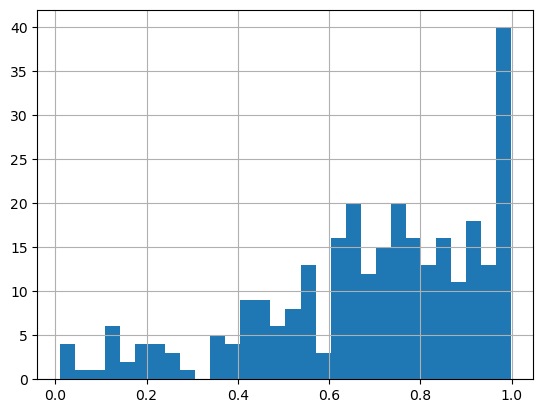

In [42]:
missing_per_station.hist(bins=30)

In [ ]:
valid_stations = missing_per_station[missing_per_station < 0.5].index
# pivot = pivot[valid_stations]
valid_stations.shape

(57,)

#### data from 1970

In [11]:
pivot_1970 = pivot.loc['1970':]

In [12]:
missing_per_station_1970 = pivot_1970.isna().mean()

missing_per_station_1970.sort_values(ascending=False)

station_id
AKRIGANJ            1.000000
CHANDITALA          1.000000
LACHMANPUR          1.000000
KUKRAHATI           1.000000
KOTALPUR            1.000000
KHATRA              1.000000
KHARGRAM            1.000000
KHANAKUL            1.000000
KALYANGANJ          1.000000
KALCHINI            1.000000
JENKA               1.000000
JAIPUR              1.000000
INDPUR              1.000000
HOWRAH              1.000000
HOOGHLY             1.000000
HENRIA              1.000000
HARINGHATA          1.000000
GOSABA              1.000000
GOPIBALLABHPUR      1.000000
GOALFORE            1.000000
GHATAL              1.000000
DUMKA               1.000000
DEULI               1.000000
DANTAN              1.000000
DALKOLA (FCS)       1.000000
LALGOLA             1.000000
MAJHIA              1.000000
MALIARA             1.000000
SALBANI             1.000000
TUFANGANJ           1.000000
TENTULIA            1.000000
TARAKESHWAR         1.000000
SIROMANIPUR         1.000000
SIMLAPAL            1.000000
SIL

<Axes: >

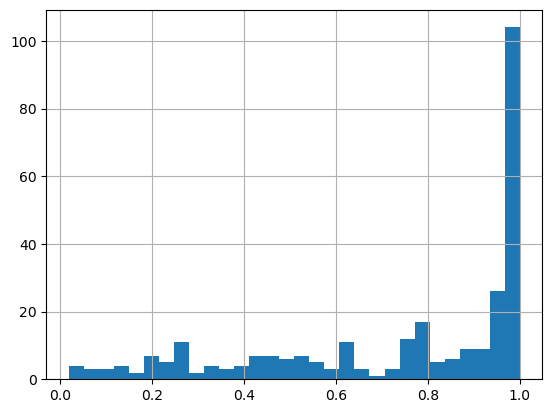

In [13]:
missing_per_station_1970.hist(bins=30)

In [15]:
df.lat.describe()

count    4.741665e+06
mean     2.401833e+01
std      1.693484e+00
min      2.085000e+01
25%      2.273000e+01
50%      2.343000e+01
75%      2.533000e+01
max      2.722000e+01
Name: lat, dtype: float64

In [16]:
bbox = [df['lat'].min(), df['lat'].max(), df['lon'].min(), df['lon'].max()]
print("Bounding box (lat_min, lat_max, lon_min, lon_max):", bbox)

Bounding box (lat_min, lat_max, lon_min, lon_max): [20.85, 27.22, 85.97, 89.83999999999999]


In [17]:
df.head()

,station_id,date,year,month,day,day_of_year,rainfall,district,station_type,lat,lon,node_id
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,MURSHIDABAD,None,24.31,88.36,0
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,MURSHIDABAD,None,24.31,88.36,0
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,MURSHIDABAD,None,24.31,88.36,0
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,MURSHIDABAD,None,24.31,88.36,0
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,MURSHIDABAD,None,24.31,88.36,0


In [18]:
stations_df = df[['station_id', 'lat', 'lon']].drop_duplicates()
stations_df.shape

(293, 3)

In [19]:
stations_df.head()

,station_id,lat,lon
0,AKRIGANJ,24.310000,88.360000
17166,ALGARAH,27.120000,88.580000
33237,ALIPUR,22.530000,88.330000
77067,ALIPURDUAR,26.470000,89.550000
113227,ALIPURDUAR(CWC),26.498333,89.528333


In [23]:
save_path = f'C:/Users/rishe/Dissertation/data/wb_station_coords.csv'
stations_df.to_csv(save_path, index=False)

In [24]:
stations_df = pd.read_csv(save_path)
stations_df.head()

,station_id,latitude,longitude
0,AKRIGANJ,24.310000,88.360000
1,ALGARAH,27.120000,88.580000
2,ALIPUR,22.530000,88.330000
3,ALIPURDUAR,26.470000,89.550000
4,ALIPURDUAR(CWC),26.498333,89.528333


In [22]:
stations_df.rename(columns={"lat": "latitude", "lon": "longitude"}, inplace=True)

#### missing values per date

In [44]:
missing_per_day = pivot.isna().mean(axis=1)
missing_per_day.sort_values(ascending=False).head(10)

date
2021-12-31    0.969283
2021-12-16    0.969283
2021-12-01    0.969283
2021-12-02    0.969283
2021-12-03    0.969283
2021-12-04    0.969283
2021-12-05    0.969283
2021-12-06    0.969283
2021-12-07    0.969283
2021-12-09    0.969283
dtype: float64

<Axes: >

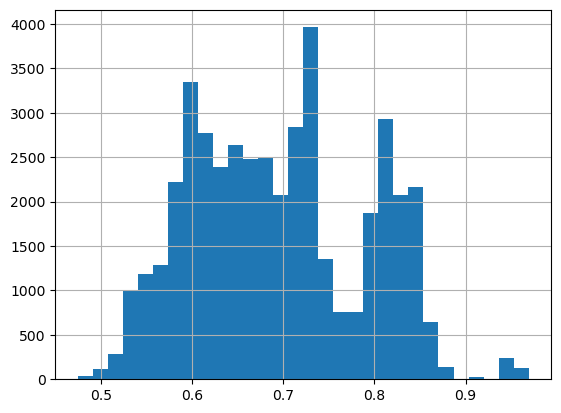

In [45]:
missing_per_day.hist(bins=30)

Text(0.5, 1.0, 'Missing Rainfall Data')

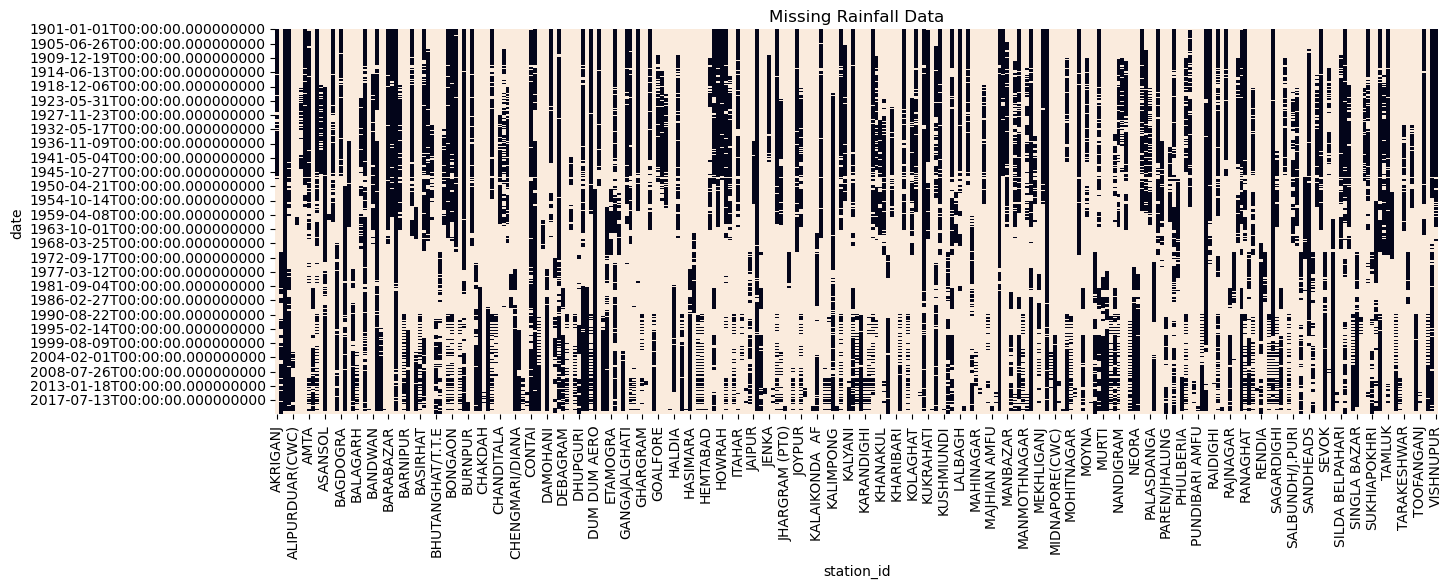

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.heatmap(pivot.isna(), cbar=False)
plt.title("Missing Rainfall Data")

##### Rainfall statistics

In [47]:
pivot.describe()

station_id,AKRIGANJ,ALGARAH,ALIPUR,ALIPURDUAR,ALIPURDUAR(CWC),ALSHA,AMBIKANAGAR,AMLAGORA,AMTA,AMTALA,ARAMBAGH,ARHARA,ASANSOL,ASANSOLE %A,AZIMGANJ,BAGATI,BAGDOGRA,BAGDOGRA AERO,BAGMANDI,BAGROKOTE,BALAGARH,BALICHAK,BALURGHAT,BAMONGOLA,BANDWAN,BANKURA,BANKURA(CWC),BANSHIHARI,BARABAZAR,BARASAT,BARHAMPORE,BARJORA,BARNIPUR,BAROBHISHA,BARRACKPORE,BARRACKPUR(IAF),BASIRHAT,BASIRHAT(DEPT),BHAGWANPUR,BHARATPUR,BHUTANGHAT/T.T.E,BIJANBARI,BOINCHEE,BOLPUR,BONGAON,BUDGE BUDGE,BURDAWAN,BURDWAN,BURNPUR,BUXA,BUXADUR,CANNING,CHAKDAH,CHAMPASARI,CHANCHAL,CHANDIPUR,CHANDITALA,CHANDRAKONA,CHATNA,CHEL,CHENGMARI/DIANA,CHEPAN,CHINSURA,CHOPRA,CONTAI,COOCH BEHAR AERO,D.P.GHAT,DALKOLA (FCS),DAMOHANI,DANTAN,DANTEN,DARJEELING,DEBAGRAM,DEGANGA,DEULI,DHANIAKHALI,DHUPGURI,DIAMOND HARBOUR,DIGHA,DINHATA,DUM DUM AERO,DUMKA,DURGACHACK,DURGAPUR,ETAMOGRA,FALAKATA,GADGHAT,GAJOLDOBA,GANGAJALGHATI,GANGARAMPUR,GARUBATHAN,GAZOLE,GHARGRAM,GHARGRAM KHEJURI,GHATAL,GHEROPARA,GOALFORE,GOPIBALLABHPUR,GOSABA,HABIBPUR,HALDIA,HARINGHATA,HARINKHOLA,HARISHCHANDRAPUR,HASIMARA,HASIMARA AERO,HATWARA,HELDIBARI,HEMTABAD,HENRIA,HETAMPUR,HOOGHLY,HOWRAH,INDAS,INDPUR,ISLAMPUR,ITAHAR,JAGATBALLARPUR,JAGATVALLAVPUR,JAIGAON,JAIPUR,JALPAIGURI,JANGIPUR,JAYANTI,JENKA,JHALDA,JHALDAH/JHALDA,JHARGRAM,JHARGRAM (PT0),JHEPI,JIAGANJ,JONGIPUR,JOYPUR,KADAMDEULI,KAKDWIP,KAKDWIP AMFU,KALAIKONDA AF,KALCHINI,KALIAGANJ,KALICHAK,KALIMPONG,KALIMPONG AMFU,KALNA,KALYANGANJ,KALYANI,KANDI,KANKSA,KANSABETI DAM,KARANDIGHI,KASHIPUR,KATWA,KESIARY KALTIKRI,KHANAKUL,KHARAGPORE,KHARAGPORE I.I.T,KHARGRAM,KHARIBARI,KHARIDWAR(CWC),KHATRA,KHIRAPAI,KOLAGHAT,KOTALPUR,KOTSHILA,KRISHNANAGAR,KUKRAHATI,KUMARGANJ,KUMARGRAM,KURSEONG,KUSHMIUNDI,LABHA(LAVA),LABPUR,LACHMANPUR,LALBAGH,LALGARH,LALGOLA,LUUCHIPUR,MAHINAGAR,MAINAGURI,MAJHIA,MAJHIAN,MAJHIAN AMFU,MALBAZAR,MALDA,MALIARA,MANBAZAR,MANGALKOT,MANGALKOTE,MANKER,MANMOTHNAGAR,MANTESWAR,MATHABHANGA,MAYURESHWAR,MEKHLIGANJ,MEKLIGANJ,MIDNAPORE,MIDNAPORE (SCRF),MIDNAPORE(CWC),MO KOLKATA,MO SALT LAKE,MOHANPUR,MOHITNAGAR,MOHUA TEA ESTAT,MONGPOO,MONTESWAR,MOYNA,MUKUTMONIPUR,MUNSONG,MURARAI,MURTI,NAGARKATA,NAKSHIPARA,NALHATI,NANDIGRAM,NARAJOLE,NARAYANGARH,NARAYANPUR,NEORA,NH31 BRIDGE,ONDA,PACHET%KHARAI,PALASDANGA,PANGARH AERO,PANSKURA,PARA,PAREN/JHALUNG,PATRASAYAR,PEDONG,PHALUT,PHULBERIA,PINGLA,POTKABARI,PUNDIBARI,PUNDIBARI AMFU,PURIHANSA,PURULIA,RAGHUNATHPUR,RAIDIGHI,RAIGANJ,RAIGANJ(PTO),RAIPUR,RAJNAGAR,RAMAN,RAMNAGAR,RAMPURHAT,RANAGHAT,RANGO,RANIBANDH,RATUA,RENDIA,RESSISUM,SABONG,SAGAR ISLAND,SAGARDIGHI,SALAR,SALBANI,SALBARI,SALBUNDH/J.PURI,SALTORA,SAMSING,SANDAKPHU,SANDHEADS,SANKOS,SARANGA,SERAMPORE,SEVOK,SHAMSUNDAR ROYNA,SHANTI NIKETAN,SHEKHAMPORE,SILDA BELPAHARI,SILIGURI,SIMLAPAL,SIMULA(CWC),SINGLA BAZAR,SINGUR,SIROMANIPUR,SONAMUKHI,SUKHIAPOKHRI,SURI,SURI(CWC),TALDANGRA,TAMLUK,TANGLU,TANTLOI,TAPAN,TARAKESHWAR,TEESTA BAZAR,TENTULIA,TILPARA BARRAGE,TOOFANGANJ,TUFANGANJ,TUSUMA(CWC),ULUBERIA,VISHNUPUR
count,15713.000000,13575.000000,43752.000000,34602.000000,4937.000000,851.000000,4901.000000,18088.000000,23741.000000,8939.000000,27350.000000,7831.000000,33572.000000,731.000000,18941.000000,17350.000000,15722.000000,23956.000000,9614.000000,12701.000000,2670.000000,11841.000000,37105.000000,62.000000,16920.000000,38741.000000,9080.000000,62.000000,23495.000000,20552.000000,41999.000000,13955.000000,5205.000000,9039.000000,20307.000000,10017.000000,4785.000000,28754.000000,19860.000000,6720.000000,7868.000000,9680.000000,8640.000000,27531.000000,25340.000000,24880.000000,3739.000000,35776.000000,1095.000000,23105.000000,11728.000000,14267.000000,593.000000,11814.000000,22057.000000,2334.000000,10727.000000,10406.000000,13476.000000,3138.000000,14303.000000,8656.000000,1861.000000,896.000000,38554.000000,39061.000000,7122.000000,3104.000000,15281.000000,17145.000000,7248.000000,38239.000000,10183.000000,4155.000000,5431.000000,4600.000000,7229.000000,35090.000000,14172.000000,25043.000000,25546.000000,16287.000000,9919.000000,20096.000000,6116.000000,33574.000000,5913.000000,6678.000000,19588.000

<Axes: >

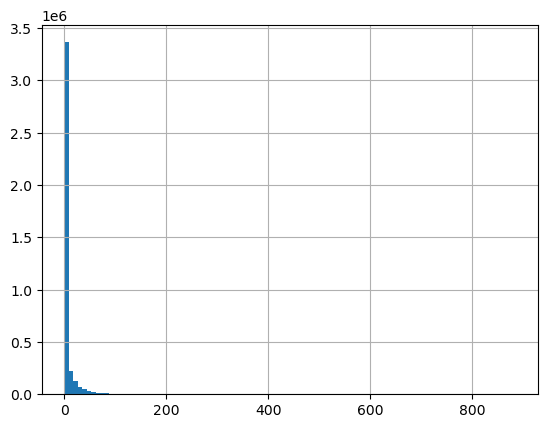

In [48]:
pivot.stack().hist(bins=100)

##### Station coorealation

<Axes: xlabel='station_id', ylabel='station_id'>

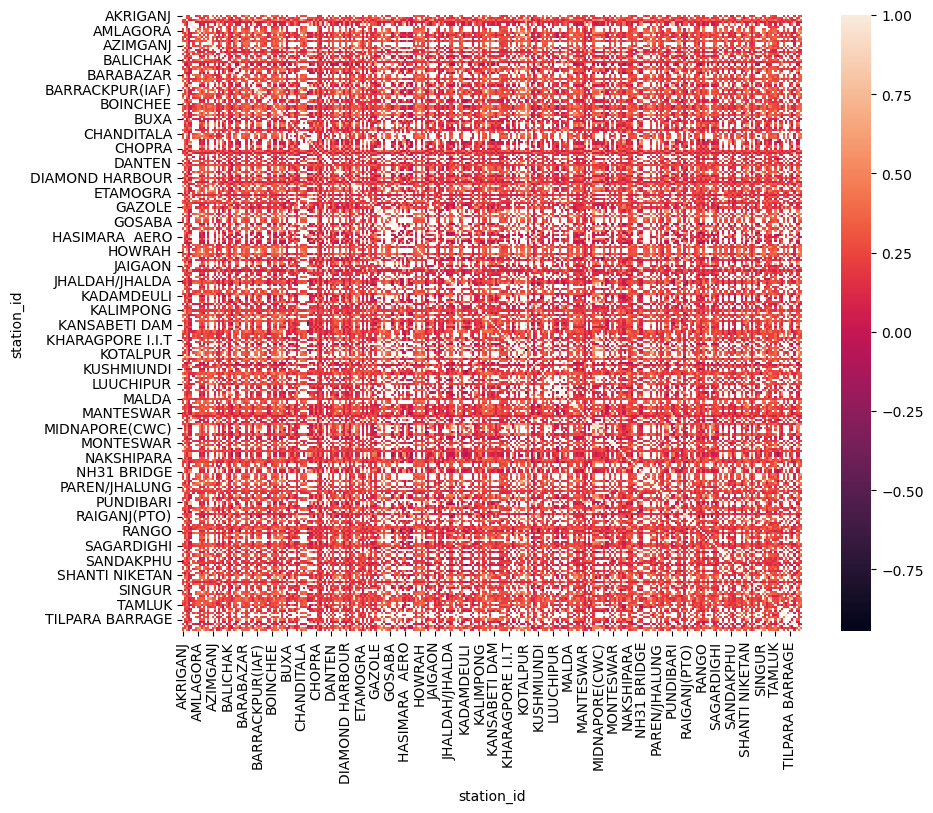

: 

In [ ]:
corr = pivot.corr()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(corr)

#### ERA 5 data

In [8]:
df.head()

,date,station_id,total_precipitation_sum,temperature_2m,dewpoint_temperature_2m,surface_pressure,u_component_of_wind_10m,v_component_of_wind_10m
0,1970-01-01,AKRIGANJ,0.000001,290.550081,282.015345,101451.001139,1.429861,-1.679754
1,1970-01-01,ALGARAH,0.000032,282.937939,279.363571,84739.084473,-0.110544,-0.104071
2,1970-01-01,ALIPUR,0.000001,291.040071,281.454554,101608.751139,0.409028,-2.243149
3,1970-01-01,ALIPURDUAR,0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159
4,1970-01-01,ALIPURDUAR(CWC),0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159


In [11]:
df[df['station_id']=='AKRIGANJ']['total_precipitation_sum'].describe()

count    365.000000
mean       0.004440
std        0.008551
min        0.000000
25%        0.000001
50%        0.000414
75%        0.005686
max        0.093468
Name: total_precipitation_sum, dtype: float64

In [14]:
(df['total_precipitation_sum']*1000.0).describe()

count    106215.000000
mean          5.383075
std          11.883855
min          -0.000028
25%           0.001717
50%           0.526084
75%           6.762105
max         403.365632
Name: total_precipitation_sum, dtype: float64

In [15]:
DATA_PATH

'C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_1970.csv'

In [16]:
npath= f'C:/Users/rishe/Dissertation/data/era5_pivot_data/rain_pivot.parquet'
p_df = pd.read_parquet(npath)
p_df.head()

station_id,AKRIGANJ,ALGARAH,ALIPUR,ALIPURDUAR,ALIPURDUAR(CWC),ALSHA,AMBIKANAGAR,AMLAGORA,AMTA,AMTALA,ARAMBAGH,ARHARA,ASANSOL,ASANSOLE %A,AZIMGANJ,BAGATI,BAGDOGRA,BAGDOGRA AERO,BAGMANDI,BAGROKOTE,BALAGARH,BALICHAK,BALURGHAT,BAMONGOLA,BANDWAN,BANKURA,BANKURA(CWC),BANSHIHARI,BARABAZAR,BARASAT,BARHAMPORE,BARJORA,BARNIPUR,BAROBHISHA,BARRACKPORE,BARRACKPUR(IAF),BASIRHAT,BASIRHAT(DEPT),BHAGWANPUR,BHARATPUR,BHUTANGHAT/T.T.E,BIJANBARI,BOINCHEE,BOLPUR,BONGAON,BUDGE BUDGE,BURDAWAN,BURDWAN,BURNPUR,BUXA,BUXADUR,CANNING,CHAKDAH,CHAMPASARI,CHANCHAL,CHANDIPUR,CHANDITALA,CHANDRAKONA,CHATNA,CHEL,CHENGMARI/DIANA,CHEPAN,CHINSURA,CHOPRA,CONTAI,COOCH BEHAR AERO,D.P.GHAT,DALKOLA (FCS),DAMOHANI,DANTAN,DANTEN,DARJEELING,DEBAGRAM,DEGANGA,DEULI,DHANIAKHALI,DHUPGURI,DIAMOND HARBOUR,DIGHA,DINHATA,DUM DUM AERO,DUMKA,DURGACHACK,DURGAPUR,ETAMOGRA,FALAKATA,GADGHAT,GAJOLDOBA,GANGAJALGHATI,GANGARAMPUR,GARUBATHAN,GAZOLE,GHARGRAM,GHARGRAM KHEJURI,GHATAL,GHEROPARA,GOALFORE,GOPIBALLABHPUR,GOSABA,HABIBPUR,HALDIA,HARINGHATA,HARINKHOLA,HARISHCHANDRAPUR,HASIMARA,HASIMARA AERO,HATWARA,HELDIBARI,HEMTABAD,HENRIA,HETAMPUR,HOOGHLY,HOWRAH,INDAS,INDPUR,ISLAMPUR,ITAHAR,JAGATBALLARPUR,JAGATVALLAVPUR,JAIGAON,JAIPUR,JALPAIGURI,JANGIPUR,JAYANTI,JENKA,JHALDA,JHALDAH/JHALDA,JHARGRAM,JHARGRAM (PT0),JHEPI,JIAGANJ,JONGIPUR,JOYPUR,KADAMDEULI,KAKDWIP,KAKDWIP AMFU,KALAIKONDA AF,KALCHINI,KALIAGANJ,KALICHAK,KALIMPONG,KALIMPONG AMFU,KALNA,KALYANGANJ,KALYANI,KANDI,KANKSA,KANSABETI DAM,KARANDIGHI,KASHIPUR,KATWA,KESIARY KALTIKRI,KHANAKUL,KHARAGPORE,KHARAGPORE I.I.T,KHARGRAM,KHARIBARI,KHARIDWAR(CWC),KHATRA,KHIRAPAI,KOLAGHAT,KOTALPUR,KOTSHILA,KRISHNANAGAR,KUKRAHATI,KUMARGANJ,KUMARGRAM,KURSEONG,KUSHMIUNDI,LABHA(LAVA),LABPUR,LACHMANPUR,LALBAGH,LALGARH,LALGOLA,LUUCHIPUR,MAHINAGAR,MAINAGURI,MAJHIA,MAJHIAN,MAJHIAN AMFU,MALBAZAR,MALDA,MALIARA,MANBAZAR,MANGALKOT,MANGALKOTE,MANKER,MANMOTHNAGAR,MANTESWAR,MATHABHANGA,MAYURESHWAR,MEKHLIGANJ,MEKLIGANJ,MIDNAPORE,MIDNAPORE (SCRF),MIDNAPORE(CWC),MO KOLKATA,MO SALT LAKE,MOHANPUR,MOHITNAGAR,MOHUA TEA ESTAT,MONGPOO,MONTESWAR,MOYNA,MUKUTMONIPUR,MUNSONG,MURARAI,MURTI,NAGARKATA,NAKSHIPARA,NALHATI,NANDIGRAM,NARAJOLE,NARAYANGARH,NARAYANPUR,NEORA,NH31 BRIDGE,ONDA,PACHET%KHARAI,PALASDANGA,PANGARH AERO,PANSKURA,PARA,PAREN/JHALUNG,PATRASAYAR,PEDONG,PHALUT,PHULBERIA,PINGLA,POTKABARI,PUNDIBARI,PUNDIBARI AMFU,PURIHANSA,PURULIA,RAGHUNATHPUR,RAIDIGHI,RAIGANJ,RAIGANJ(PTO),RAIPUR,RAJNAGAR,RAMAN,RAMNAGAR,RAMPURHAT,RANAGHAT,RANGO,RANIBANDH,RATUA,RENDIA,RESSISUM,SABONG,SAGARDIGHI,SALAR,SALBANI,SALBARI,SALBUNDH/J.PURI,SALTORA,SAMSING,SANDAKPHU,SANKOS,SARANGA,SERAMPORE,SEVOK,SHAMSUNDAR ROYNA,SHANTI NIKETAN,SHEKHAMPORE,SILDA BELPAHARI,SILIGURI,SIMLAPAL,SIMULA(CWC),SINGLA BAZAR,SINGUR,SIROMANIPUR,SONAMUKHI,SUKHIAPOKHRI,SURI,SURI(CWC),TALDANGRA,TAMLUK,TANGLU,TANTLOI,TAPAN,TARAKESHWAR,TEESTA BAZAR,TENTULIA,TILPARA BARRAGE,TOOFANGANJ,TUFANGANJ,TUSUMA(CWC),ULUBERIA,VISHNUPUR
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1970-01-01,0.001266,0.032082,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.007257,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001475,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.437543,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.011399,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.001266,0.005916,0.001266,0.